Successfully loaded your custom image: /content/zoltan-tasi-yanhwFwyoaU-unsplash.jpg


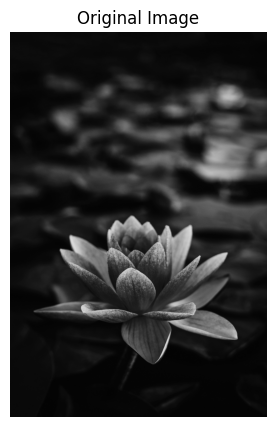

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

my_image_path = '/content/zoltan-tasi-yanhwFwyoaU-unsplash.jpg'

if os.path.exists(my_image_path):
    image = cv2.imread(my_image_path, cv2.IMREAD_GRAYSCALE)
    print(f"Successfully loaded your custom image: {my_image_path}")
else:
    print(f"File '{my_image_path}' not found. Generating a synthetic image for demonstration.")
    image = np.zeros((300, 300), dtype=np.uint8)
    image[50:150, 50:150] = 100
    image[150:250, 150:250] = 200
    noise = np.random.normal(0, 15, image.shape).astype(np.int16)
    image = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [9]:
hist, bin_edges = np.histogram(image, bins=256, range=(0, 256))
p_i = hist / float(image.size)
cumulative_sum = np.cumsum(p_i)

def fitness_otsu(thresholds):
    t = np.sort(np.round(thresholds).astype(int))
    t = np.clip(t, 1, 254)
    bounds = [0] + list(t) + [255]

    num_classes = len(bounds) - 1

    w = np.zeros(num_classes)
    mu = np.zeros(num_classes)
    global_mean = np.sum(np.arange(256) * p_i)

    for i in range(num_classes):
        lower = bounds[i]
        upper = bounds[i+1]

        w[i] = np.sum(p_i[lower:upper])
        if w[i] == 0:
            w[i] = 1e-10

        mu[i] = np.sum(np.arange(lower, upper) * p_i[lower:upper]) / w[i]
    between_class_variance = np.sum(w * (mu - global_mean)**2)

    return between_class_variance

In [10]:
def pso_thresholding(num_particles=30, max_iter=50, num_thresholds=2):
    dim = num_thresholds
    X = np.random.uniform(1, 254, (num_particles, dim))
    V = np.random.uniform(-5, 5, (num_particles, dim))
    pbest_position = np.copy(X)
    pbest_fitness = np.array([fitness_otsu(pos) for pos in X])

    gbest_idx = np.argmax(pbest_fitness)
    gbest_position = np.copy(pbest_position[gbest_idx])
    gbest_fitness = pbest_fitness[gbest_idx]

    w = 0.7
    c1 = 1.5
    c2 = 1.5

    for iteration in range(max_iter):
        for i in range(num_particles):
            r1, r2 = np.random.rand(dim), np.random.rand(dim)

            V[i] = (w * V[i] +
                    c1 * r1 * (pbest_position[i] - X[i]) +
                    c2 * r2 * (gbest_position - X[i]))

            V[i] = np.clip(V[i], -10, 10)


            X[i] = X[i] + V[i]
            X[i] = np.clip(X[i], 1, 254)


            current_fitness = fitness_otsu(X[i])


            if current_fitness > pbest_fitness[i]:
                pbest_fitness[i] = current_fitness
                pbest_position[i] = np.copy(X[i])

        current_gbest_idx = np.argmax(pbest_fitness)
        if pbest_fitness[current_gbest_idx] > gbest_fitness:
            gbest_fitness = pbest_fitness[current_gbest_idx]
            gbest_position = np.copy(pbest_position[current_gbest_idx])

    best_thresholds = np.sort(np.round(gbest_position).astype(int))
    return best_thresholds

Optimized Thresholds found by PSO: [ 64 121]


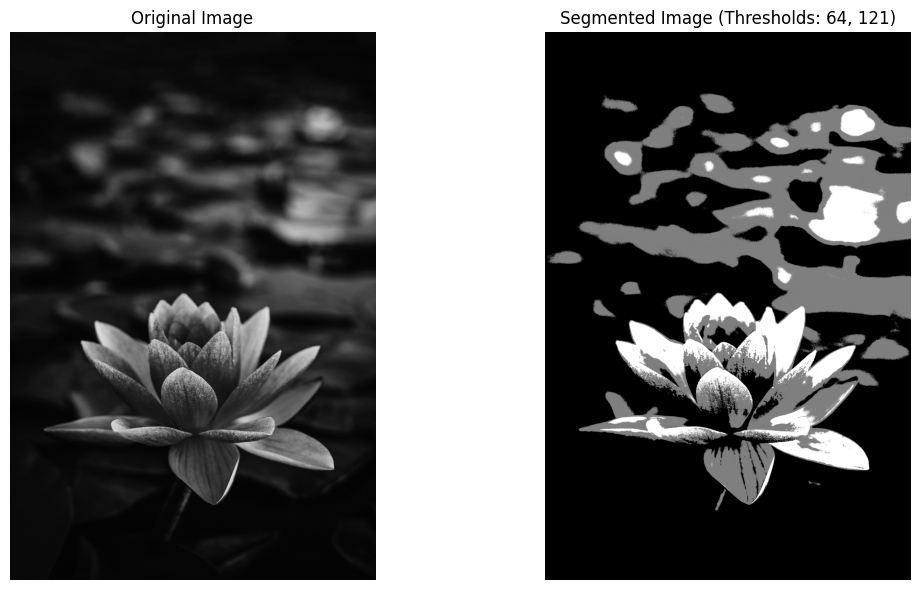

In [11]:
best_t = pso_thresholding(num_particles=20, max_iter=40, num_thresholds=2)
print(f"Optimized Thresholds found by PSO: {best_t}")

segmented_image = np.zeros_like(image)
segmented_image[image > best_t[0]] = 127
segmented_image[image > best_t[1]] = 255

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(segmented_image, cmap='gray')
axes[1].set_title(f'Segmented Image (Thresholds: {best_t[0]}, {best_t[1]})')
axes[1].axis('off')

plt.tight_layout()
plt.show()